In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
ev = pd.read_csv("data/events.csv")
print(ev.shape)
print(ev.dtypes)
print(ev["event"].value_counts())
ev.head()

(2756101, 5)
timestamp          int64
visitorid          int64
event                str
itemid             int64
transactionid    float64
dtype: object
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [4]:
ev["ts"] = pd.to_datetime(ev["timestamp"], unit="ms")
print("من:", ev["ts"].min(), "إلى:", ev["ts"].max())
print("المدة:", (ev["ts"].max() - ev["ts"].min()).days, "يوماً")
print("مستخدمون:", ev["visitorid"].nunique(), "| منتجات:", ev["itemid"].nunique())

من: 2015-05-03 03:00:04.384000 إلى: 2015-09-18 02:59:47.788000
المدة: 137 يوماً
مستخدمون: 1407580 | منتجات: 235061


In [5]:
u = ev.groupby("visitorid").size()
i = ev.groupby("itemid").size()

print("=== المستخدمون ===")
print(u.describe(percentiles=[.5, .9, .99]).round(1).to_string())
for k in [1, 2, 5, 10, 20]:
    n = (u >= k).sum()
    print(f"  لهم {k:>2}+ حدث: {n:>9,} ({n/len(u)*100:5.1f}%)")

print("\n=== المنتجات ===")
print(i.describe(percentiles=[.5, .9, .99]).round(1).to_string())
for k in [1, 5, 10, 50]:
    n = (i >= k).sum()
    print(f"  لها {k:>2}+ حدث: {n:>9,} ({n/len(i)*100:5.1f}%)")

=== المستخدمون ===
count    1407580.0
mean           2.0
std           12.6
min            1.0
50%            1.0
90%            3.0
99%           13.0
max         7757.0
  لهم  1+ حدث: 1,407,580 (100.0%)
  لهم  2+ حدث:   406,020 ( 28.8%)
  لهم  5+ حدث:    81,620 (  5.8%)
  لهم 10+ حدث:    23,241 (  1.7%)
  لهم 20+ حدث:     6,610 (  0.5%)

=== المنتجات ===
count    235061.0
mean         11.7
std          37.0
min           1.0
50%           3.0
90%          25.0
99%         143.0
max        3412.0
  لها  1+ حدث:   235,061 (100.0%)
  لها  5+ حدث:    90,948 ( 38.7%)
  لها 10+ حدث:    55,128 ( 23.5%)
  لها 50+ حدث:    11,166 (  4.8%)


In [6]:
top = u.sort_values(ascending=False).head(20)
print(top.to_string())

visitorid
1150086    7757
530559     4328
152963     3024
895999     2474
163561     2410
371606     2345
286616     2252
684514     2246
892013     2024
861299     1991
836635     1934
76757      1883
638482     1829
1297062    1822
316850     1752
247235     1698
1161163    1663
994820     1661
79627      1623
518659     1614


In [7]:
top20 = u.sort_values(ascending=False).head(20).index

e = ev[ev["visitorid"].isin(top20)].copy()
e["ts"] = pd.to_datetime(e["timestamp"], unit="ms")
e = e.sort_values(["visitorid", "ts"])

gap = e.groupby("visitorid")["ts"].diff().dt.total_seconds()
e["gap"] = gap

prof = e.groupby("visitorid").agg(
    n_events   = ("ts", "size"),
    n_days     = ("ts", lambda s: s.dt.date.nunique()),
    gap_median = ("gap", "median"),
    gap_std    = ("gap", "std"),
    sub_1s     = ("gap", lambda s: (s < 1).mean()),
).round(2)

print(prof.sort_values("n_events", ascending=False).to_string())

           n_events  n_days  gap_median   gap_std  sub_1s
visitorid                                                
1150086        7757      74      107.60  12226.95    0.01
530559         4328      73       99.30  17015.69    0.02
152963         3024      38      118.02  12955.59    0.04
895999         2474      97      221.86  36009.98    0.00
163561         2410      21       68.36  17524.46    0.03
371606         2345      18       81.05  14027.52    0.03
286616         2252      19       61.69  15219.32    0.02
684514         2246      18       90.67  31929.69    0.03
892013         2024      42       22.76  20526.94    0.00
861299         1991      21      107.82  13410.90    0.04
836635         1934      16       62.29   9015.44    0.02
76757          1883      28      109.99  26269.93    0.04
638482         1829      81      164.08  29746.22    0.05
1297062        1822      24      131.97  15322.61    0.03
316850         1752     130      125.08  19958.46    0.01
247235        

In [8]:
def mad(s):
    return (s - s.median()).abs().median()

prof2 = e.groupby("visitorid").agg(
    n_events   = ("ts", "size"),
    n_days     = ("ts", lambda s: s.dt.date.nunique()),
    gap_median = ("gap", "median"),
    gap_mad    = ("gap", mad),
).round(2)

prof2["disp"]           = (prof2["gap_mad"] / prof2["gap_median"]).round(2)
prof2["per_active_day"] = (prof2["n_events"] / prof2["n_days"]).round(1)

print(prof2.sort_values("n_events", ascending=False).to_string())

           n_events  n_days  gap_median  gap_mad  disp  per_active_day
visitorid                                                             
1150086        7757      74      107.60    82.99  0.77           104.8
530559         4328      73       99.30    81.89  0.82            59.3
152963         3024      38      118.02    95.26  0.81            79.6
895999         2474      97      221.86   191.60  0.86            25.5
163561         2410      21       68.36    62.90  0.92           114.8
371606         2345      18       81.05    70.88  0.87           130.3
286616         2252      19       61.69    52.05  0.84           118.5
684514         2246      18       90.67    74.41  0.82           124.8
892013         2024      42       22.76     9.64  0.42            48.2
861299         1991      21      107.82    91.19  0.85            94.8
836635         1934      16       62.29    52.33  0.84           120.9
76757          1883      28      109.99    98.33  0.89            67.2
638482

In [9]:
# مقاييس التنوّع للعشرين
div20 = e.groupby("visitorid").agg(
    n_events = ("itemid", "size"),
    n_items  = ("itemid", "nunique"),
).assign(reps = lambda d: (d.n_events / d.n_items).round(2))

print(div20.sort_values("n_events", ascending=False).to_string())

# توزيع تكرار المنتج الواحد داخل كل مستخدم
per_item = e.groupby(["visitorid", "itemid"]).size()
print(per_item.groupby("visitorid").describe().round(1).to_string())

           n_events  n_items  reps
visitorid                         
1150086        7757     3814  2.03
530559         4328     2209  1.96
152963         3024     1622  1.86
895999         2474     1641  1.51
163561         2410     1314  1.83
371606         2345     1399  1.68
286616         2252     1230  1.83
684514         2246     1187  1.89
892013         2024     1738  1.16
861299         1991     1100  1.81
836635         1934     1029  1.88
76757          1883      929  2.03
638482         1829     1133  1.61
1297062        1822     1146  1.59
316850         1752      998  1.76
247235         1698      958  1.77
1161163        1663      943  1.76
994820         1661      912  1.82
79627          1623     1257  1.29
518659         1614      716  2.25
            count  mean  std  min  25%  50%  75%   max
visitorid                                             
76757       929.0   2.0  1.5  1.0  1.0  1.0  3.0  10.0
79627      1257.0   1.3  0.9  1.0  1.0  1.0  1.0  17.0
152963    

In [10]:
ctrl_ids = u[(u >= 50) & (u <= 300)].sample(20, random_state=0).index
c = ev[ev["visitorid"].isin(ctrl_ids)]

divc = c.groupby("visitorid").agg(
    n_events = ("itemid", "size"),
    n_items  = ("itemid", "nunique"),
).assign(reps = lambda d: (d.n_events / d.n_items).round(2))

print(divc.sort_values("n_events", ascending=False).to_string())

           n_events  n_items  reps
visitorid                         
896347          152       71  2.14
560891          149       70  2.13
542983          145       48  3.02
682621          128       45  2.84
824082          100       52  1.92
983013           96       63  1.52
457187           91       57  1.60
1212999          85       25  3.40
810368           77       40  1.92
75424            74       25  2.96
1306828          73       32  2.28
730800           64       39  1.64
1018140          58       21  2.76
784869           57       27  2.11
607827           57       34  1.68
19702            56       14  4.00
633718           55       15  3.67
547545           54       44  1.23
1177303          52       25  2.08
501958           51       31  1.65


In [11]:
mid_ids = u[(u >= 500) & (u <= 1000)].sample(20, random_state=0).index
m = ev[ev["visitorid"].isin(mid_ids)]

divm = m.groupby("visitorid").agg(
    n_events = ("itemid", "size"),
    n_items  = ("itemid", "nunique"),
).assign(reps = lambda d: (d.n_events / d.n_items).round(2))

print(divm.sort_values("n_events", ascending=False).to_string())

           n_events  n_items  reps
visitorid                         
527307          937      818  1.15
825321          895      609  1.47
1165148         858      620  1.38
1327144         852      580  1.47
1143383         736      456  1.61
57905           732      439  1.67
974226          694      415  1.67
227091          692      451  1.53
591869          650      452  1.44
477826          647      418  1.55
316600          636      374  1.70
95405           631      433  1.46
952246          604      342  1.77
971454          590      403  1.46
416496          585      117  5.00
1015599         562      301  1.87
1357576         559      458  1.22
404403          539      338  1.59
899857          528      204  2.59
1313381         507      236  2.15


In [12]:
def mix(df, label):
    p = (df.pivot_table(index="visitorid", columns="event",
                        values="itemid", aggfunc="size")
           .fillna(0))
    for c in ["view", "addtocart", "transaction"]:
        if c not in p:
            p[c] = 0
    p["n"] = p[["view", "addtocart", "transaction"]].sum(axis=1)
    p["cart_rate"] = (p["addtocart"] / p["view"]).round(3)
    p["buy_rate"]  = (p["transaction"] / p["addtocart"]).round(3)
    p["grp"] = label
    return p[["grp", "n", "view", "addtocart", "transaction",
              "cart_rate", "buy_rate"]]

out = pd.concat([mix(e, "top20"), mix(m, "mid"), mix(c, "ctrl")])
print(out.sort_values(["grp", "n"], ascending=[True, False]).to_string())

print(out.groupby("grp")[["cart_rate", "buy_rate"]].median().round(3).to_string())

event        grp       n    view  addtocart  transaction  cart_rate  buy_rate
visitorid                                                                    
896347      ctrl   152.0   117.0       18.0         17.0      0.154     0.944
560891      ctrl   149.0   125.0       23.0          1.0      0.184     0.043
542983      ctrl   145.0   145.0        0.0          0.0      0.000       NaN
682621      ctrl   128.0   123.0        5.0          0.0      0.041     0.000
824082      ctrl   100.0    91.0        4.0          5.0      0.044     1.250
983013      ctrl    96.0    96.0        0.0          0.0      0.000       NaN
457187      ctrl    91.0    91.0        0.0          0.0      0.000       NaN
1212999     ctrl    85.0    27.0       34.0         24.0      1.259     0.706
810368      ctrl    77.0    77.0        0.0          0.0      0.000       NaN
75424       ctrl    74.0    52.0       12.0         10.0      0.231     0.833
1306828     ctrl    73.0    73.0        0.0          0.0      0.

In [13]:
act = ev.groupby("visitorid").size()
cand = act[act >= 20].index          # الفئة القابلة للقياس

a = ev[ev["visitorid"].isin(cand)].copy()
a["ts"] = pd.to_datetime(a["timestamp"], unit="ms")
a = a.sort_values(["visitorid", "ts"])
a["gap"] = a.groupby("visitorid")["ts"].diff().dt.total_seconds()

def mad(s):
    return (s - s.median()).abs().median()

z = a.groupby("visitorid").agg(
    n          = ("ts", "size"),
    gap_median = ("gap", "median"),
    gap_mad    = ("gap", mad),
)
z["disp"] = z["gap_mad"] / z["gap_median"]

p = (a.pivot_table(index="visitorid", columns="event",
                   values="itemid", aggfunc="size").fillna(0))
for col in ["view", "addtocart", "transaction"]:
    if col not in p:
        p[col] = 0

z["cart_rate"] = (p["addtocart"] / p["view"]).replace([np.inf], np.nan)
z["buys"]      = p["transaction"]

print(z["disp"].describe().round(3).to_string())
print(z["cart_rate"].describe().round(4).to_string())
print((z["cart_rate"] < 0.005).sum(), (z["disp"] < 0.5).sum())

count    6610.000
mean        0.763
std         0.192
min         0.000
25%         0.630
50%         0.796
75%         0.932
max         1.000
count    6606.0000
mean        0.1118
std         0.7083
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0889
max        31.0000
3539 713


In [14]:
ev["ts"] = pd.to_datetime(ev["timestamp"], unit="ms")

wk = ev.groupby([pd.Grouper(key="ts", freq="W"), "event"]).size().unstack(fill_value=0)
wk["total"] = wk.sum(axis=1)
wk["users"] = ev.groupby(pd.Grouper(key="ts", freq="W"))["visitorid"].nunique()

print(wk.to_string())

event       addtocart  transaction    view   total  users
ts                                                       
2015-05-03        296           83   13304   13683   7865
2015-05-10       3492         1103  129180  133775  72138
2015-05-17       3642         1218  144001  148861  80409
2015-05-24       3419         1061  148034  152514  83929
2015-05-31       3520         1146  137153  141819  79192
2015-06-07       3405         1174  141866  146445  79273
2015-06-14       3081          966  127805  131852  73177
2015-06-21       4036         1316  140624  145976  76996
2015-06-28       3520         1222  136946  141688  75970
2015-07-05       3337         1089  134807  139233  75834
2015-07-12       3948         1302  156595  161845  92610
2015-07-19       3702         1259  147282  152243  89182
2015-07-26       4293         1357  169787  175437  97609
2015-08-02       3881         1344  139112  144337  82238
2015-08-09       3552         1073  123934  128559  75463
2015-08-16    

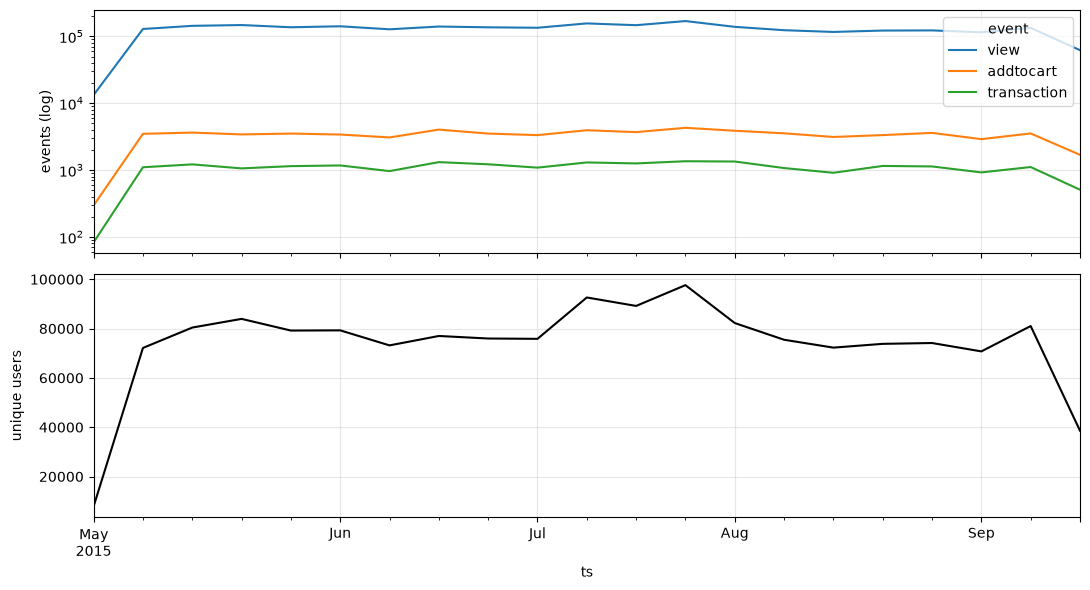

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

wk[["view", "addtocart", "transaction"]].plot(ax=ax[0], logy=True)
ax[0].set_ylabel("events (log)")
ax[0].grid(alpha=.3)

wk["users"].plot(ax=ax[1], color="k")
ax[1].set_ylabel("unique users")
ax[1].grid(alpha=.3)

plt.tight_layout()
plt.show()

In [16]:
vis = (ev.assign(day=ev["ts"].dt.floor("D"))
         .groupby("visitorid")["day"].apply(lambda s: s.drop_duplicates().sort_values()))

vg = vis.groupby("visitorid").diff().dt.days.dropna()

print(vg.describe(percentiles=[.25, .5, .75, .9]).round(1).to_string())
print("\nusers with >1 active day:", vg.index.nunique())

count    241954.0
mean         13.8
std          21.3
min           1.0
25%           1.0
50%           4.0
75%          16.0
90%          42.7
max         137.0

users with >1 active day: 241954


In [17]:
per_user = vis.groupby("visitorid").apply(lambda s: s.diff().dt.days.median()).dropna()

print(per_user.describe(percentiles=[.25, .5, .75, .9]).round(1).to_string())
print("users counted:", len(per_user))

count    143769.0
mean         16.2
std          22.7
min           1.0
25%           2.0
50%           6.0
75%          21.0
90%          48.0
max         137.0
users counted: 143769


In [18]:
cut1 = pd.Timestamp("2015-08-08")   # نهاية البناء
cut2 = pd.Timestamp("2015-08-29")   # نهاية التحقق

for lo, hi, name in [(cut1, cut2, "valid"), (cut2, ev["ts"].max(), "test")]:
    before = set(ev.loc[ev["ts"] < lo, "visitorid"])
    after  = set(ev.loc[(ev["ts"] >= lo) & (ev["ts"] < hi), "visitorid"])
    both   = before & after
    print(name, "| before:", len(before), "| after:", len(after), "| crossed:", len(both))

valid | before: 1031923 | after: 210849 | crossed: 17909
test | before: 1224863 | after: 201393 | crossed: 18676


In [19]:
before = ev.loc[ev["ts"] < cut2, ["visitorid"]]
n_before = before.groupby("visitorid").size()

after_ids = set(ev.loc[ev["ts"] >= cut2, "visitorid"])

for th in [1, 2, 3, 5, 10, 20]:
    elig = set(n_before[n_before >= th].index)
    print(f"th={th:>3} | eligible: {len(elig):>8} | crossed: {len(elig & after_ids):>7}")

th=  1 | eligible:  1224863 | crossed:   18676
th=  2 | eligible:   352002 | crossed:    9908
th=  3 | eligible:   173963 | crossed:    6647
th=  5 | eligible:    71454 | crossed:    3877
th= 10 | eligible:    20457 | crossed:    1750
th= 20 | eligible:     5858 | crossed:     815


In [20]:
from scipy.sparse import csr_matrix
from sklearn.preprocessing import normalize

W = {"view": 1, "addtocart": 3, "transaction": 5}

b = ev[ev["ts"] < cut1].copy()
b["w"] = b["event"].map(W)

b["u"] = b["visitorid"].astype("category")
b["i"] = b["itemid"].astype("category")

M = csr_matrix(
    (b["w"].values, (b["u"].cat.codes, b["i"].cat.codes)),
    shape=(b["u"].cat.categories.size, b["i"].cat.categories.size),
)
M.sum_duplicates()

Mn = normalize(M, axis=0)          # كل عمود منتج بطول واحد
S  = (Mn.T @ Mn).tocsr()           # تشابه جيبي بين المنتجات
S.setdiag(0)
S.eliminate_zeros()

print(M.shape, M.nnz)
print("similarity nnz:", S.nnz)

(1031923, 205468) 1576808
similarity nnz: 40756356


In [21]:
import numpy as np

def top_k(S, k=100):
    S = S.tocsr()
    rows, cols, vals = [], [], []
    for r in range(S.shape[0]):
        s, e = S.indptr[r], S.indptr[r + 1]
        if e - s == 0:
            continue
        d, v = S.indices[s:e], S.data[s:e]
        if len(v) > k:
            idx = np.argpartition(v, -k)[-k:]
            d, v = d[idx], v[idx]
        rows.append(np.full(len(d), r)); cols.append(d); vals.append(v)
    return csr_matrix(
        (np.concatenate(vals), (np.concatenate(rows), np.concatenate(cols))),
        shape=S.shape,
    )

Sk = top_k(S, k=100)
print("after top-k:", Sk.nnz)

after top-k: 4378118


In [22]:
nb = ev[ev["ts"] < cut1].groupby("visitorid").size()
va = set(ev.loc[(ev["ts"] >= cut1) & (ev["ts"] < cut2), "visitorid"])
eval_users = set(nb[nb >= 5].index) & va
print(len(eval_users))

3764


In [24]:
nb = ev[ev["ts"] < cut1].groupby("visitorid").size()
va = set(ev.loc[(ev["ts"] >= cut1) & (ev["ts"] < cut2), "visitorid"])
eval_users = set(nb[nb >= 5].index) & va
print("eval users:", len(eval_users))

i_cats = b["i"].cat.categories
i_pos  = {it: p for p, it in enumerate(i_cats)}

hb = b[b["visitorid"].isin(eval_users) & b["itemid"].isin(i_pos)].copy()
hb["code"] = hb["itemid"].map(i_pos).astype(int)

truth = (ev[(ev["ts"] >= cut1) & (ev["ts"] < cut2)]
           .groupby("visitorid")["itemid"].apply(set))

hits = tot = 0
for uid, g in hb.groupby("visitorid"):
    if uid not in truth:
        continue
    codes = g["code"].values
    w     = g["w"].values.astype(float)

    scores = np.asarray(w @ Sk[codes]).ravel()
    scores[codes] = -1

    rec = {i_cats[p] for p in np.argpartition(scores, -10)[-10:]}
    hits += len(rec & truth[uid]) > 0
    tot  += 1

print(f"HitRate@10: {hits/tot:.4f}  ({hits}/{tot})")

eval users: 3764
HitRate@10: 0.0207  (78/3764)


In [25]:
pop = (b.groupby("itemid")["w"].sum()
         .sort_values(ascending=False).head(10).index)
pop = set(pop)

h = sum(len(pop & truth[u]) > 0 for u in hb["visitorid"].unique() if u in truth)
print(f"Popularity@10: {h/tot:.4f}  ({h}/{tot})")

Popularity@10: 0.0173  (65/3764)


In [26]:
print(truth[list(hb["visitorid"].unique())].apply(len).describe().round(1))

count    3764.0
mean        4.8
std        26.5
min         1.0
25%         1.0
50%         1.0
75%         3.0
max       674.0
Name: itemid, dtype: float64


In [27]:
def build_and_eval(W, k=100, n=10):
    bb = ev[ev["ts"] < cut1].copy()
    bb["w"] = bb["event"].map(W).astype(float)
    bb["u"] = bb["visitorid"].astype("category")
    bb["i"] = bb["itemid"].astype("category")

    M = csr_matrix((bb["w"].values, (bb["u"].cat.codes, bb["i"].cat.codes)),
                   shape=(bb["u"].cat.categories.size, bb["i"].cat.categories.size))
    M.sum_duplicates()

    Mn = normalize(M, axis=0)
    S = (Mn.T @ Mn).tocsr()
    S.setdiag(0); S.eliminate_zeros()
    Sk = top_k(S, k=k)

    cats = bb["i"].cat.categories
    pos  = {it: p for p, it in enumerate(cats)}

    h = bb[bb["visitorid"].isin(eval_users) & bb["itemid"].isin(pos)].copy()
    h["code"] = h["itemid"].map(pos).astype(int)

    hits = tot = 0
    for uid, g in h.groupby("visitorid"):
        if uid not in truth:
            continue
        codes = g["code"].values
        sc = np.asarray(g["w"].values @ Sk[codes]).ravel()
        sc[codes] = -1
        rec = {cats[p] for p in np.argpartition(sc, -n)[-n:]}
        hits += len(rec & truth[uid]) > 0
        tot  += 1
    return hits, tot, hits / tot

for name, W in [("1/3/5", {"view":1,"addtocart":3,"transaction":5}),
                ("1/12/36", {"view":1,"addtocart":12,"transaction":36})]:
    hi, to, r = build_and_eval(W)
    print(f"{name:>8} | HitRate@10: {r:.4f}  ({hi}/{to})")

   1/3/5 | HitRate@10: 0.0207  (78/3764)
 1/12/36 | HitRate@10: 0.0170  (64/3764)
